# LSTM MODEL

In [4]:
import pickle
import numpy as np

with open('data/processed_data.pkl', 'rb') as f:
    payload = pickle.load(f)

if isinstance(payload, dict):
    X_train = payload['X_train']
    X_test = payload['X_test']
    y_train = payload['y_train']
    y_test = payload['y_test']
    target_scaler = payload['target_scaler']
    feature_cols = payload.get('feature_cols', [])
else:
    # Backward compatibility with old tuple format
    X_train, X_test, y_train, y_test, scaler = payload
    target_scaler = scaler
    feature_cols = ['Close']

# Keep this alias for compatibility with downstream cells
scaler = target_scaler

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Features:', feature_cols)

X_train shape: (1094, 60, 11)
X_test shape: (274, 60, 11)
Features: ['Close', 'Open', 'High', 'Low', 'Volume', 'MA20', 'MA50', 'RSI', 'BB_upper', 'BB_lower', 'Returns']


In [12]:
# LSTM model building (stabilized for less overfitting)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(48, return_sequences=True),
    Dropout(0.3),

    LSTM(24, return_sequences=False),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1)
])

optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='huber')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 48)         │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,945 (74.00 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Callbacks for stable validation behavior
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/lstm_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [14]:
# Train the model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

history = model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/100
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0095

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0101 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0153 - val_loss: 0.0128 - learning_rate: 5.0000e-04
Epoch 3/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0041

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0058 - val_loss: 0.0025 - learning_rate: 5.0000e-04
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0067 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0059 - val_loss: 0.0027 - learning_rate: 5.0000e-04
Epoch 6/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0038

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0058 - val_loss: 0.0024 - learning_rate: 5.0000e-04
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0050 - val_loss: 0.0024 - learning_rate: 5.0000e-04
Epoch 8/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0034

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0050 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0035

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0042 - val_loss: 0.0021 - learning_rate: 5.0000e-04
Epoch 12/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0031

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0042 - val_loss: 0.0021 - learning_rate: 5.0000e-04
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0041 - val_loss: 0.0021 - learning_rate: 5.0000e-04
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0039 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 15/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0029

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0042 - val_loss: 0.0020 - learning_rate: 5.0000e-04
Epoch 16/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0032

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0042 - val_loss: 0.0020 - learning_rate: 5.0000e-04
Epoch 17/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0037 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 18/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0038 - val_loss: 0.0024 - learning_rate: 5.0000e-04
Epoch 19/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0043 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 20/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0051 - val_loss: 0.0027 - learning_rate: 5.0000e-04
Epoch 21/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0039 - val_loss: 0.0037 - learning_rate: 5.0000e-04
Epoch 22/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0052 - val_loss: 0.0020 - learning_rate: 5.0000e-04
Epoch 23/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0056 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 24/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0024


Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0038 - val_loss: 0.0019 - learning_rate: 5.0000e-04
Epoch 25/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0035 - val_loss: 0.0024 - learning_rate: 2.5000e-04
Epoch 26/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0034 - val_loss: 0.0023 - learning_rate: 2.5000e-04
Epoch 27/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0030 - val_loss: 0.0025 - learning_rate: 2.5000e-04
Epoch 28/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0029 - val_loss: 0.0023 - learning_rate: 2.5000e-04
Epoch 29/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0028 - val_loss: 0.0023 - learning_rate: 2.5000e-04
Epoch 30/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0030 - val_loss: 0.0022 - learning_rate: 2.5000e-04
Epoch 31/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0030 - val_loss: 0.0020 - learning_rate: 2.5000e-04
Epoch 32/100
13

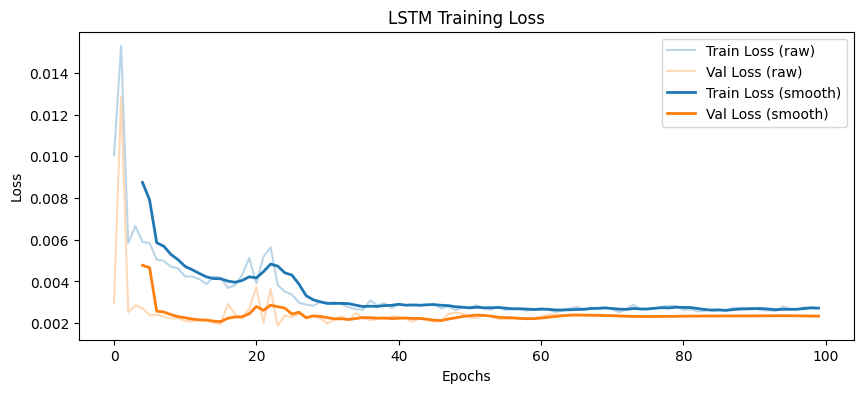

In [15]:
# Plot training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:blue', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:orange', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:blue', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:orange', linewidth=2)

plt.title('LSTM Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
# Evaluate the best saved model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_model = load_model('models/lstm_model.h5', compile=False)
y_pred_scaled = best_model.predict(X_test, verbose=0)

# Inverse transform back to price values
y_pred = target_scaler.inverse_transform(y_pred_scaled).reshape(-1)
y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / np.clip(np.abs(y_actual), 1e-8, None))) * 100

print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f'MAPE : {mape:.2f}%')

RMSE : 556.98
MAE  : 422.50
MAPE : 2.17%


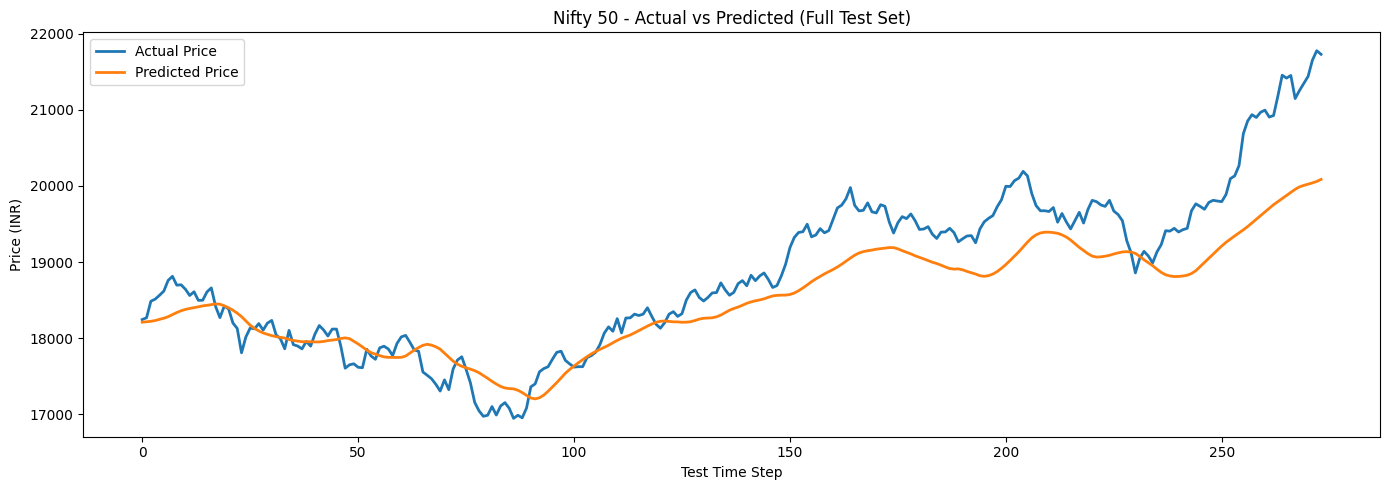

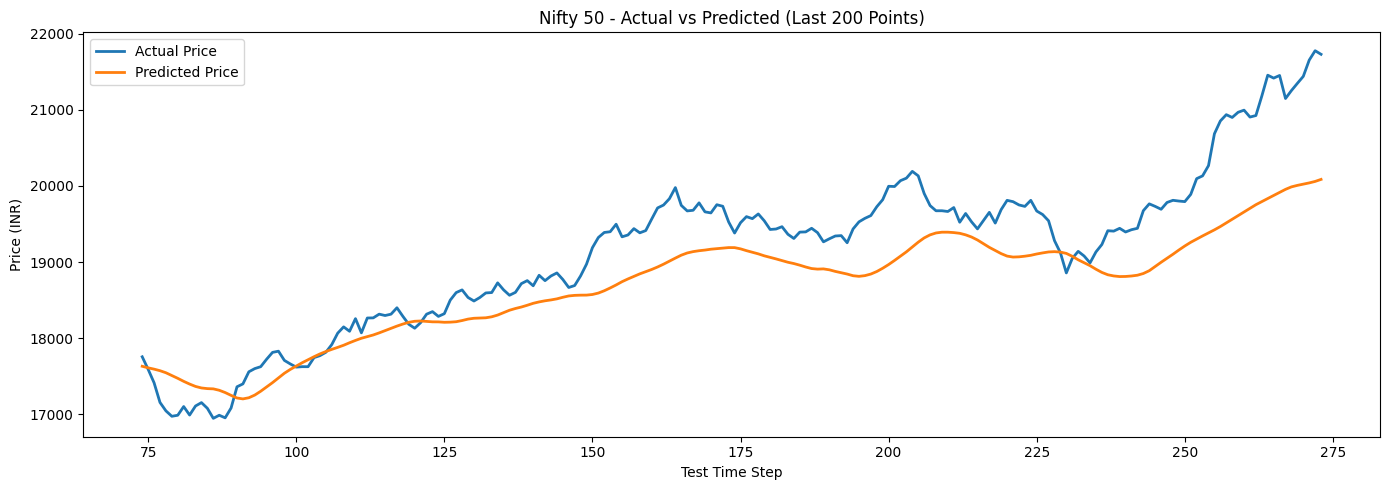

In [17]:
# Plot predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, y_pred, label='Predicted Price', color='tab:orange', linewidth=2)
plt.title('Nifty 50 - Actual vs Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], y_pred[-zoom:], label='Predicted Price', color='tab:orange', linewidth=2)
plt.title(f'Nifty 50 - Actual vs Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()


# GRU MODEL

In [6]:
# GRU model building (stabilized for less overfitting)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(48, return_sequences=True),
    Dropout(0.3),
    
    GRU(24, return_sequences=False),
    Dropout(0.3),
    
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1)
])

optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
gru_model.compile(optimizer=optimizer, loss='huber')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 48)         │         8,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 24)             │         5,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,529 (56.75 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callbacks for stable validation behavior (GRU)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

gru_callbacks = [
    ModelCheckpoint("models/gru_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [8]:
# Train the GRU model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

gru_history = gru_model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=gru_callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0121

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0182 - val_loss: 0.0121 - learning_rate: 5.0000e-04
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0136 - val_loss: 0.0135 - learning_rate: 5.0000e-04
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0082 - val_loss: 0.0141 - learning_rate: 5.0000e-04
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0051

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0071 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0061 - val_loss: 0.0104 - learning_rate: 5.0000e-04
Epoch 6/100
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0042

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0059 - val_loss: 0.0082 - learning_rate: 5.0000e-04
Epoch 7/100
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0038

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0055 - val_loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0055 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 9/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0035

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0052 - val_loss: 0.0070 - learning_rate: 5.0000e-04
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0048 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 11/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0032

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0049 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0047 - val_loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0044 - val_loss: 0.0061 - learning_rate: 5.0000e-04
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0041 - val_loss: 0.0094 - learning_rate: 5.0000e-04
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0044 - val_loss: 0.0066 - learning_rate: 5.0000e-04
Epoch 16/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0040 - val_loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 17/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0039 - val_loss: 0.0084 - learning_rate: 5.0000e-04
Epoch 18/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0039 - val_loss: 0.0083 - learning_rate: 5.0000e-04
Epoch 19/100
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0029
Epoch 19: ReduceLROnPlate

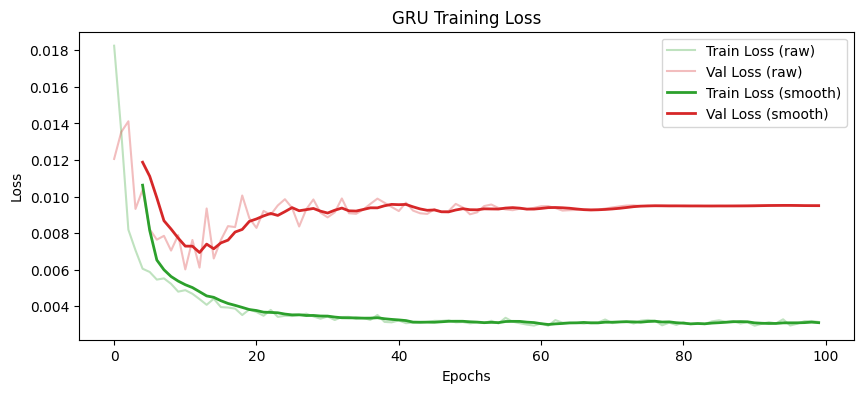

In [9]:
# Plot GRU training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = gru_history.history['loss']
val_loss = gru_history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:green', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:red', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:green', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:red', linewidth=2)

plt.title('GRU Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
# Evaluate the best saved GRU model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_gru_model = load_model('models/gru_model.h5', compile=False)
gru_y_pred_scaled = best_gru_model.predict(X_test, verbose=0)

# Inverse transform back to price values
gru_y_pred = target_scaler.inverse_transform(gru_y_pred_scaled).reshape(-1)
gru_y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

gru_rmse = np.sqrt(mean_squared_error(gru_y_actual, gru_y_pred))
gru_mae = mean_absolute_error(gru_y_actual, gru_y_pred)
gru_mape = np.mean(np.abs((gru_y_actual - gru_y_pred) / np.clip(np.abs(gru_y_actual), 1e-8, None))) * 100

print(f'GRU RMSE : {gru_rmse:.2f}')
print(f'GRU MAE  : {gru_mae:.2f}')
print(f'GRU MAPE : {gru_mape:.2f}%')

GRU RMSE : 1801.14
GRU MAE  : 1735.79
GRU MAPE : 9.11%


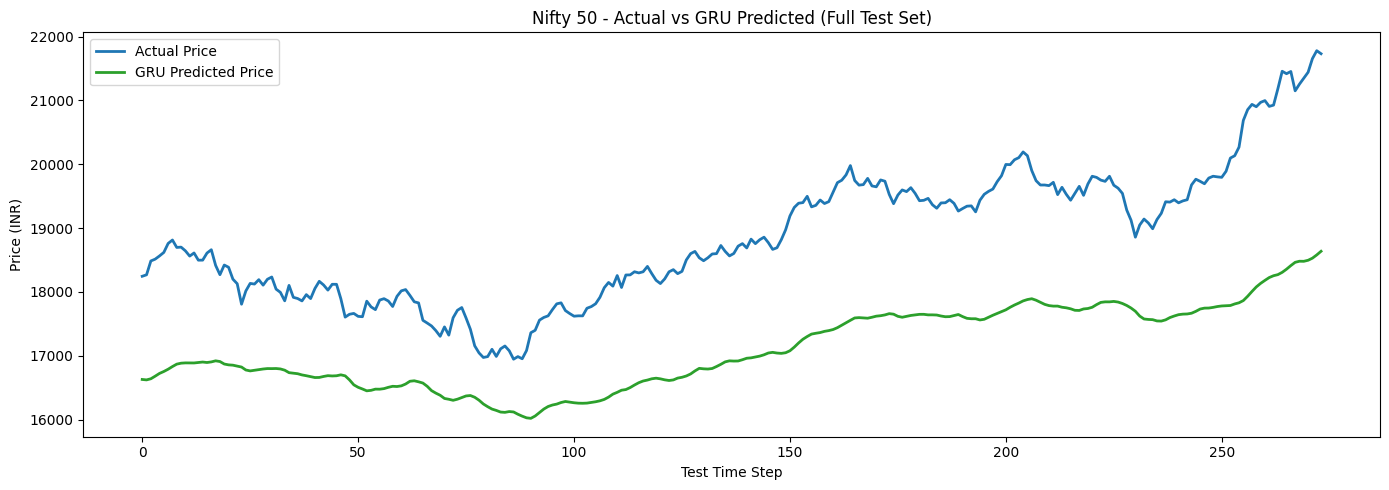

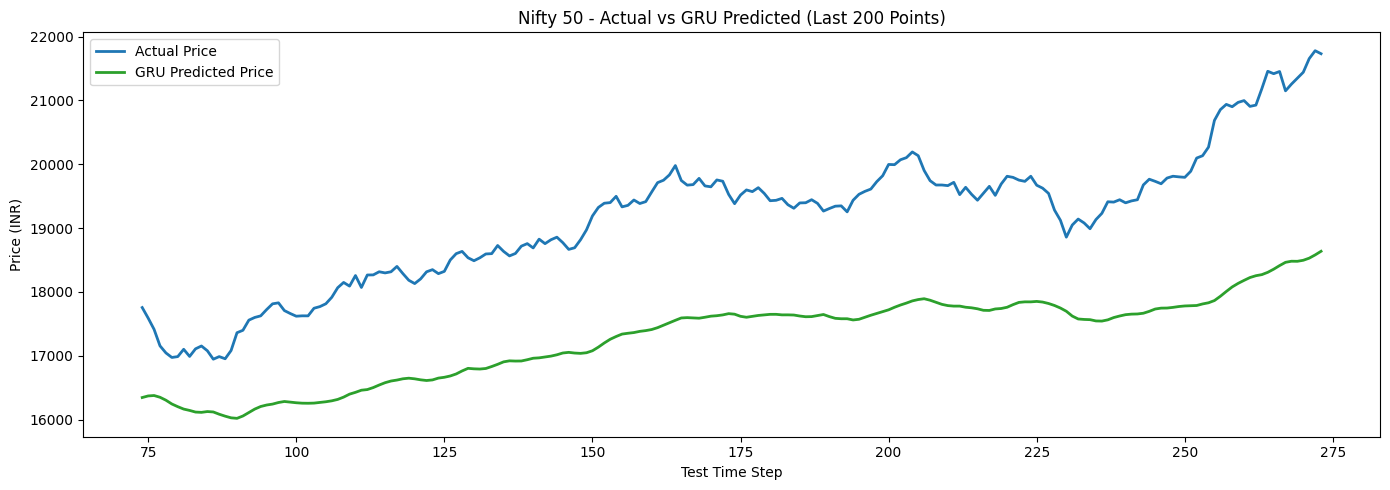

In [11]:
# Plot GRU predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(gru_y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, gru_y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, gru_y_pred, label='GRU Predicted Price', color='tab:green', linewidth=2)
plt.title('Nifty 50 - Actual vs GRU Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], gru_y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], gru_y_pred[-zoom:], label='GRU Predicted Price', color='tab:green', linewidth=2)
plt.title(f'Nifty 50 - Actual vs GRU Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# TRANSFORMER MODEL

In [23]:
# Transformer model building with Multi-Head Self-Attention
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

# Build Transformer-based model
def create_transformer_model(input_shape, num_heads=4, ff_dim=128):
    inputs = Input(shape=input_shape)
    x = inputs
    
    # Multi-Head Self-Attention
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=32)(x, x)
    attention_output = Dropout(0.3)(attention_output)
    x = LayerNormalization(epsilon=1e-6)(x + attention_output)
    
    # Feed Forward Network
    ff_output = Dense(ff_dim, activation='relu')(x)
    ff_output = Dropout(0.3)(ff_output)
    ff_output = Dense(input_shape[-1])(ff_output)
    x = LayerNormalization(epsilon=1e-6)(x + ff_output)
    
    # Global pooling and dense layers
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

transformer_model = create_transformer_model((X_train.shape[1], X_train.shape[2]))
optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
transformer_model.compile(optimizer=optimizer, loss='huber')
transformer_model.summary()

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 11)    │      6,027 │ input_layer_3[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 60, 11)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 60, 11)    │          0 │ input_layer_3[0]… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 11)    │         22 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 60, 128)   │      1,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 60, 128)   │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 60, 11)    │      1,419 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 60, 11)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 11)    │         22 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 11)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │        768 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         33 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,907 (46.51 KB)

 Trainable params: 11,907 (46.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for stable validation behavior (Transformer)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

transformer_callbacks = [
    ModelCheckpoint("models/transformer_model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [34]:
# Train the Transformer model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

transformer_history = transformer_model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=transformer_callbacks,
    shuffle=False,
    verbose=1
)

# Save the trained model
transformer_model.save('models/transformer_model.keras')

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0028 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0029 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0028 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0031 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0030 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0032 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0026 - val_loss: 0.0011 - 

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0030 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 80/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0029 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 81/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0029 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 82/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 83/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0028 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 84/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0028 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 85/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 86/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 87/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0028 - val_loss: 0.0011 - lear

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 91/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0021

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0032 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 92/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0019

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0028 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 93/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0018

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 94/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0020

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0028 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 95/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0029 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 96/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0031 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 97/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0030 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 98/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0030 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 99/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0030 - val_loss: 0.0011 - learning_rate: 1.0000e-06
Epoch 100/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0027 - val_loss: 0.0011 - learning_rate: 1.0000e-06


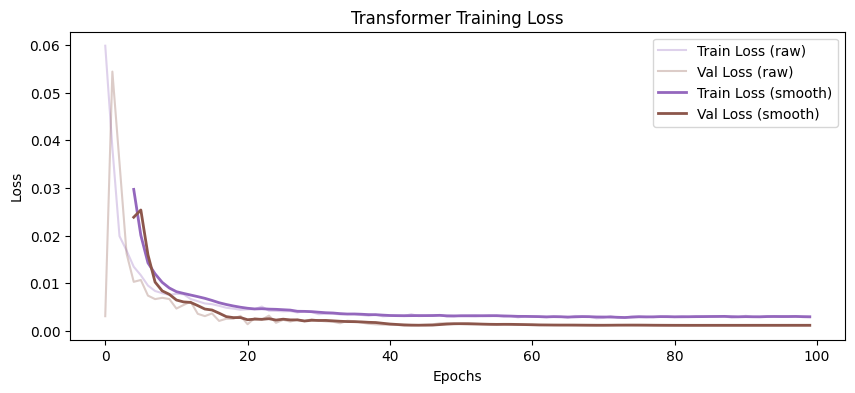

In [29]:
# Plot Transformer training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = transformer_history.history['loss']
val_loss = transformer_history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:purple', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:brown', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:purple', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:brown', linewidth=2)

plt.title('Transformer Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [35]:
# Evaluate the best saved Transformer model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_transformer_model = load_model('models/transformer_model.keras', compile=False)
transformer_y_pred_scaled = best_transformer_model.predict(X_test, verbose=0)

# Inverse transform back to price values
transformer_y_pred = target_scaler.inverse_transform(transformer_y_pred_scaled).reshape(-1)
transformer_y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

transformer_rmse = np.sqrt(mean_squared_error(transformer_y_actual, transformer_y_pred))
transformer_mae = mean_absolute_error(transformer_y_actual, transformer_y_pred)
transformer_mape = np.mean(np.abs((transformer_y_actual - transformer_y_pred) / np.clip(np.abs(transformer_y_actual), 1e-8, None))) * 100

print(f'Transformer RMSE : {transformer_rmse:.2f}')
print(f'Transformer MAE  : {transformer_mae:.2f}')
print(f'Transformer MAPE : {transformer_mape:.2f}%')

Transformer RMSE : 1354.82
Transformer MAE  : 1088.29
Transformer MAPE : 5.57%


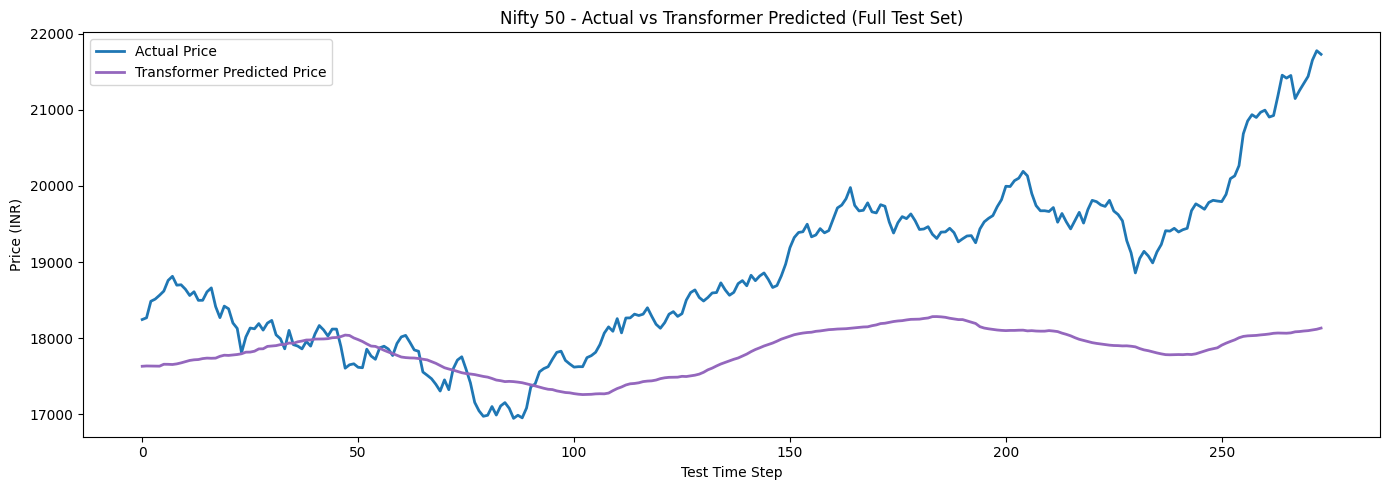

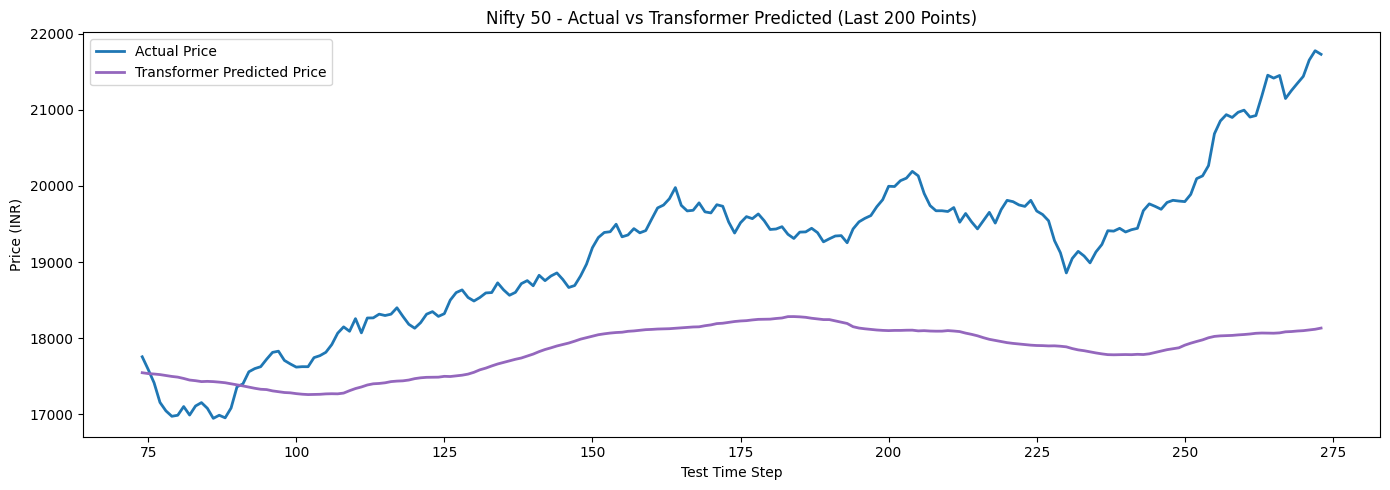

In [36]:
# Plot Transformer predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(transformer_y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, transformer_y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, transformer_y_pred, label='Transformer Predicted Price', color='tab:purple', linewidth=2)
plt.title('Nifty 50 - Actual vs Transformer Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], transformer_y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], transformer_y_pred[-zoom:], label='Transformer Predicted Price', color='tab:purple', linewidth=2)
plt.title(f'Nifty 50 - Actual vs Transformer Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# CNN + LSTM MODEL

In [ ]:
# CNN + LSTM model building
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

cnn_lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(48, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1)
])

optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
cnn_lstm_model.compile(optimizer=optimizer, loss='huber')
cnn_lstm_model.summary()

In [ ]:
# Callbacks for stable validation behavior (CNN + LSTM)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

cnn_lstm_callbacks = [
    ModelCheckpoint("models/cnn_lstm_model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# Train the CNN + LSTM model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

cnn_lstm_history = cnn_lstm_model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=cnn_lstm_callbacks,
    shuffle=False,
    verbose=1
)

In [ ]:
# Plot CNN + LSTM training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = cnn_lstm_history.history['loss']
val_loss = cnn_lstm_history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:cyan', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:pink', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:cyan', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:pink', linewidth=2)

plt.title('CNN + LSTM Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the best saved CNN + LSTM model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_cnn_lstm_model = load_model('models/cnn_lstm_model.keras', compile=False)
cnn_lstm_y_pred_scaled = best_cnn_lstm_model.predict(X_test, verbose=0)

# Inverse transform back to price values
cnn_lstm_y_pred = target_scaler.inverse_transform(cnn_lstm_y_pred_scaled).reshape(-1)
cnn_lstm_y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

cnn_lstm_rmse = np.sqrt(mean_squared_error(cnn_lstm_y_actual, cnn_lstm_y_pred))
cnn_lstm_mae = mean_absolute_error(cnn_lstm_y_actual, cnn_lstm_y_pred)
cnn_lstm_mape = np.mean(np.abs((cnn_lstm_y_actual - cnn_lstm_y_pred) / np.clip(np.abs(cnn_lstm_y_actual), 1e-8, None))) * 100

print(f'CNN+LSTM RMSE : {cnn_lstm_rmse:.2f}')
print(f'CNN+LSTM MAE  : {cnn_lstm_mae:.2f}')
print(f'CNN+LSTM MAPE : {cnn_lstm_mape:.2f}%')

In [ ]:
# Plot CNN + LSTM predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(cnn_lstm_y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, cnn_lstm_y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, cnn_lstm_y_pred, label='CNN+LSTM Predicted Price', color='tab:cyan', linewidth=2)
plt.title('Nifty 50 - Actual vs CNN+LSTM Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], cnn_lstm_y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], cnn_lstm_y_pred[-zoom:], label='CNN+LSTM Predicted Price', color='tab:cyan', linewidth=2)
plt.title(f'Nifty 50 - Actual vs CNN+LSTM Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()